# Recherche : Dynamic VIX-SPY Regime avec ML Overlay

**Strategie source** : QC Strategy Library #50 - Dynamic VIX-SPY Regime Switching
**OOS 1Y Sharpe** : 1.72 | **5Y CAGR** : 29.76% | **5Y MaxDD** : 17.80% | **Win Rate** : 70%

## Contexte

Cette strategie alloue dynamiquement entre 4 classes d actifs (SPY, TLT, GLD, BIL)
en fonction du regime de volatilite detecte par le VIX. Un RandomForestClassifier
est entraine mensuellement sur 11 features VIX/SPY pour predire les mouvements
bullish a 21 jours. La probabilite ML modifie les allocations dans chaque regime.

## Objectifs de recherche

1. Sensibilite au seuil de probabilite ML (threshold)
2. Impact des frontieres de regime VIX
3. Robustese des poids d allocation
4. Taille de fenetre d entrainement
5. Importance des features et regime analysis


> **[REFERENCE QC Cloud]**
> Ce notebook utilise des modeles ML lourds (RandomForest/XGBoost/VIX) necessitant des donnees QC Cloud.
> Pour executer : https://www.quantconnect.com/research


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
print("Imports OK")


Imports OK


## Tableau des hypotheses

| ID | Hypothese | Parametre | Valeur base | Test |
|----|-----------|-----------|-------------|------|
| H1 | Le seuil ML optimal est superieur a 0.6 | `ml_threshold` | 0.60 | 0.40 - 0.80 |
| H2 | Les frontieres VIX peuvent etre optimisees | `vix_low`, `vix_high` | 13, 25 | 10-16, 20-30 |
| H3 | Une exposition brute plus elevee ameliore le rendement | `gross_exposure` | 1.50 | 1.0 - 2.0 |
| H4 | Une fenetre d entrainement plus longue ameliore la robustesse | `train_years` | 4 | 2 - 6 |
| H5 | Le regime VIX calme beneficie le plus du ML | regime analysis | - | par regime |


In [2]:
TICKERS = ['SPY', 'TLT', 'GLD', 'BIL']
DATA_START = '2015-01-01'
DATA_END = '2025-12-31'

print("Telechargement donnees yfinance...")
raw = yf.download(TICKERS + ['^VIX'], start=DATA_START, end=DATA_END, auto_adjust=True)

# Extract close prices
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'][TICKERS].dropna()
    vix_raw = raw['Close']['^VIX'].dropna()
else:
    prices = raw[TICKERS].dropna()
    vix_raw = raw['^VIX'].dropna()

vix = vix_raw.reindex(prices.index).ffill().bfill()
prices = prices.reindex(vix.index).dropna()

print(f"Periode: {prices.index[0].date()} a {prices.index[-1].date()}")
print(f"Jours de trading: {len(prices)}")
print(f"\nRendements annuels (SPY):")
spy_ret = prices['SPY'].pct_change().dropna()
ann_ret = spy_ret.resample('YE').apply(lambda x: (1+x).prod()-1)
for y, r in ann_ret.items():
    print(f"  {y.year}: {r:.1%}")


Telechargement donnees yfinance...


[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[*********************100%***********************]  5 of 5 completed

Periode: 2015-01-02 a 2025-12-30
Jours de trading: 2765

Rendements annuels (SPY):
  2015: 1.3%
  2016: 12.0%
  2017: 21.7%
  2018: -4.6%
  2019: 31.2%
  2020: 18.3%
  2021: 28.7%
  2022: -18.2%
  2023: 26.2%
  2024: 24.9%
  2025: 18.6%


In [3]:
def calculate_metrics(equity_curve, risk_free=0.04):
    rets = equity_curve.pct_change().dropna()
    if len(rets) < 2:
        return {'Sharpe': 0, 'CAGR': 0, 'MaxDD': 0, 'WinRate': 0}
    years = len(rets) / 252
    cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (1/years) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = (cagr - risk_free) / ann_vol if ann_vol > 0 else 0
    cummax = equity_curve.cummax()
    dd = (equity_curve - cummax) / cummax
    max_dd = dd.min()
    win_rate = (rets > 0).mean()
    return {'Sharpe': round(sharpe, 3), 'CAGR': round(cagr, 4),
            'MaxDD': round(max_dd, 4), 'WinRate': round(win_rate, 3),
            'CAGR_pct': f"{cagr:.1%}", 'MaxDD_pct': f"{max_dd:.1%}"}

def plot_equity(equity, title="Equity Curve", benchmark=None):
    fig, ax = plt.subplots()
    ax.plot(equity.index, equity.values, label='Strategy', linewidth=1.2)
    if benchmark is not None:
        ax.plot(benchmark.index, benchmark.values, label='Benchmark',
                linewidth=0.8, alpha=0.7)
    ax.set_title(title)
    ax.set_ylabel('Valeur ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drawdown(equity, title="Drawdown"):
    cummax = equity.cummax()
    dd = (equity - cummax) / cummax
    fig, ax = plt.subplots()
    ax.fill_between(dd.index, dd.values, 0, color='red', alpha=0.4)
    ax.set_title(title)
    ax.set_ylabel('Drawdown')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Utilitaires charges")


Utilitaires charges


## Moteur de backtest simplifie

Le moteur reproduit la logique a 5 branches de la strategie originale :
1. **VIX spike + oversold** : VIX > p80 et SPY -3% sur 5j -> defensif
2. **VIX calme + extended** : VIX < seuil_bas et SPY > sma50*1.05 -> diversifie
3. **VIX eleve + descendant** : 20 < VIX < sma -> prudent avec GLD
4. **VIX montant** : VIX > sma*1.2 -> tres defensif (GLD 50%)
5. **Defaut trend-following** : SPY vs sma200 -> long ou reduit

Le ML overlay (RandomForest, seuil par defaut 0.6) augmente l exposition
lorsque la probabilite de hausse SPY a 21j depasse le seuil.

**Parametres configurables** : ml_threshold, vix_low, gross, train_window,
vix_sma_mult, vix_pctile


In [4]:
def get_features(vix_vals, spy_vals):
    if len(vix_vals) < 50 or len(spy_vals) < 200:
        return None
    cv = float(vix_vals[-1])
    vs20 = float(np.mean(vix_vals[-20:]))
    vs50 = float(np.mean(vix_vals[-50:]))
    vstd = float(np.std(vix_vals[-20:]))
    vz = (cv - vs20) / vstd if vstd > 0 else 0.0
    vpctl = float(np.sum(vix_vals < cv)) / float(len(vix_vals))
    sc = float(spy_vals[-1])
    ss50 = float(np.mean(spy_vals[-50:]))
    ss200 = float(np.mean(spy_vals[-200:]))
    r5 = float(spy_vals[-1] / spy_vals[-5] - 1)
    r10 = float(spy_vals[-1] / spy_vals[-10] - 1)
    r20 = float(spy_vals[-1] / spy_vals[-20] - 1)
    sv = np.diff(spy_vals[-21:]) / spy_vals[-21:-1]
    svol = float(np.std(sv) * np.sqrt(252))
    return [cv, vz, vpctl, cv/vs20 if vs20 else 1.0,
            cv/vs50 if vs50 else 1.0,
            r5, r10, r20, sc/ss50 if ss50 else 1.0,
            sc/ss200 if ss200 else 1.0, svol]


def backtest_dvs(prices, vix, params=None):
    p = {
        'ml_threshold': 0.6, 'vix_low': 13, 'gross': 1.5,
        'train_window': 504, 'vix_sma_mult': 1.2, 'vix_pctile': 80
    }
    if params:
        p.update(params)

    spy_c = prices['SPY'].values.astype(float)
    tlt_c = prices['TLT'].values.astype(float)
    gld_c = prices['GLD'].values.astype(float)
    bil_c = prices['BIL'].values.astype(float)
    vix_c = vix.values.astype(float)
    idx = prices.index
    n = len(prices)
    min_warmup = max(200, p['train_window'])

    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    scaler = StandardScaler()
    trained = False

    equity = np.ones(n)

    for i in range(1, n):
        if i < min_warmup:
            if spy_c[i-1] > 0:
                equity[i] = equity[i-1] * (spy_c[i] / spy_c[i-1])
            else:
                equity[i] = equity[i-1]
            continue

        # ML training every 21 days
        tw = p['train_window']
        if i % 21 == 0 and i >= tw + 200:
            X, y = [], []
            for j in range(200, min(len(spy_c) - 21, i)):
                feats = get_features(vix_c[:j], spy_c[:j])
                if feats is None:
                    continue
                label = 1 if spy_c[j+21] / spy_c[j] > 1.02 else 0
                X.append(feats)
                y.append(label)
            if len(X) >= 100:
                X = np.array(X)
                y = np.array(y)
                scaler.fit(X)
                model.fit(scaler.transform(X), y)
                trained = True

        # ML prediction
        ml_bullish = False
        if trained:
            feats = get_features(vix_c[:i], spy_c[:i])
            if feats is not None:
                prob_arr = model.predict_proba(scaler.transform([feats]))[0]
                prob = float(prob_arr[1]) if len(prob_arr) == 2 else 0.5
                ml_bullish = prob > p['ml_threshold']

        # Regime detection
        cv = float(vix_c[i-1])
        vix_sma = float(np.mean(vix_c[max(0,i-20):i]))
        ls = max(0, i - tw)
        vix_p80 = float(np.percentile(vix_c[ls:i], p['vix_pctile'])) if i > ls + 20 else 30.0
        spy_curr = float(spy_c[i-1])
        spy_sma50 = float(np.mean(spy_c[max(0,i-50):i]))
        spy_sma200 = float(np.mean(spy_c[max(0,i-200):i]))
        spy_5d = float(spy_c[i-1] / spy_c[max(0,i-5)] - 1)

        G = p['gross']
        w_spy, w_tlt, w_gld, w_bil = 0.0, 0.0, 0.0, 0.0

        if cv > vix_p80 and spy_5d < -0.03:
            wt = 1.0 if ml_bullish else 0.85
            w_spy = G * wt
            w_gld = G * (1 - wt)
        elif cv < p['vix_low'] and spy_curr > spy_sma50 * 1.05:
            w_spy = G * 0.4
            w_gld = G * 0.4
            w_tlt = G * 0.2
        elif 20 < cv < vix_sma:
            wt = 0.85 if ml_bullish else 0.70
            w_spy = G * wt
            w_gld = G * (1 - wt)
        elif cv > vix_sma * p['vix_sma_mult']:
            w_gld = G * 0.5
            w_bil = G * 0.3
            w_tlt = G * 0.2
        else:
            if spy_curr > spy_sma200:
                base = 0.90 if ml_bullish else 0.70
                w_spy = G * base
                w_gld = G * (1 - base) * 0.5
                w_tlt = G * (1 - base) * 0.5
            else:
                w_spy = G * 0.3
                w_gld = G * 0.5
                w_tlt = G * 0.2

        # Portfolio return
        spy_r = (spy_c[i] / spy_c[i-1] - 1) if spy_c[i-1] > 0 else 0
        tlt_r = (tlt_c[i] / tlt_c[i-1] - 1) if tlt_c[i-1] > 0 else 0
        gld_r = (gld_c[i] / gld_c[i-1] - 1) if gld_c[i-1] > 0 else 0
        bil_r = (bil_c[i] / bil_c[i-1] - 1) if bil_c[i-1] > 0 else 0
        port_ret = w_spy * spy_r + w_tlt * tlt_r + w_gld * gld_r + w_bil * bil_r
        equity[i] = equity[i-1] * (1 + port_ret)

    eq = pd.Series(equity, index=idx)
    return eq, calculate_metrics(eq)


### Execution de reference (baseline)

=== Baseline (parametres defaut) ===
  Sharpe: 0.97
  CAGR: 0.2383
  MaxDD: -0.2209
  WinRate: 0.552
  CAGR_pct: 23.8%
  MaxDD_pct: -22.1%

=== Benchmark SPY Buy & Hold ===
  Sharpe: 0.536
  CAGR: 0.1354
  MaxDD: -0.3372
  WinRate: 0.548
  CAGR_pct: 13.5%
  MaxDD_pct: -33.7%


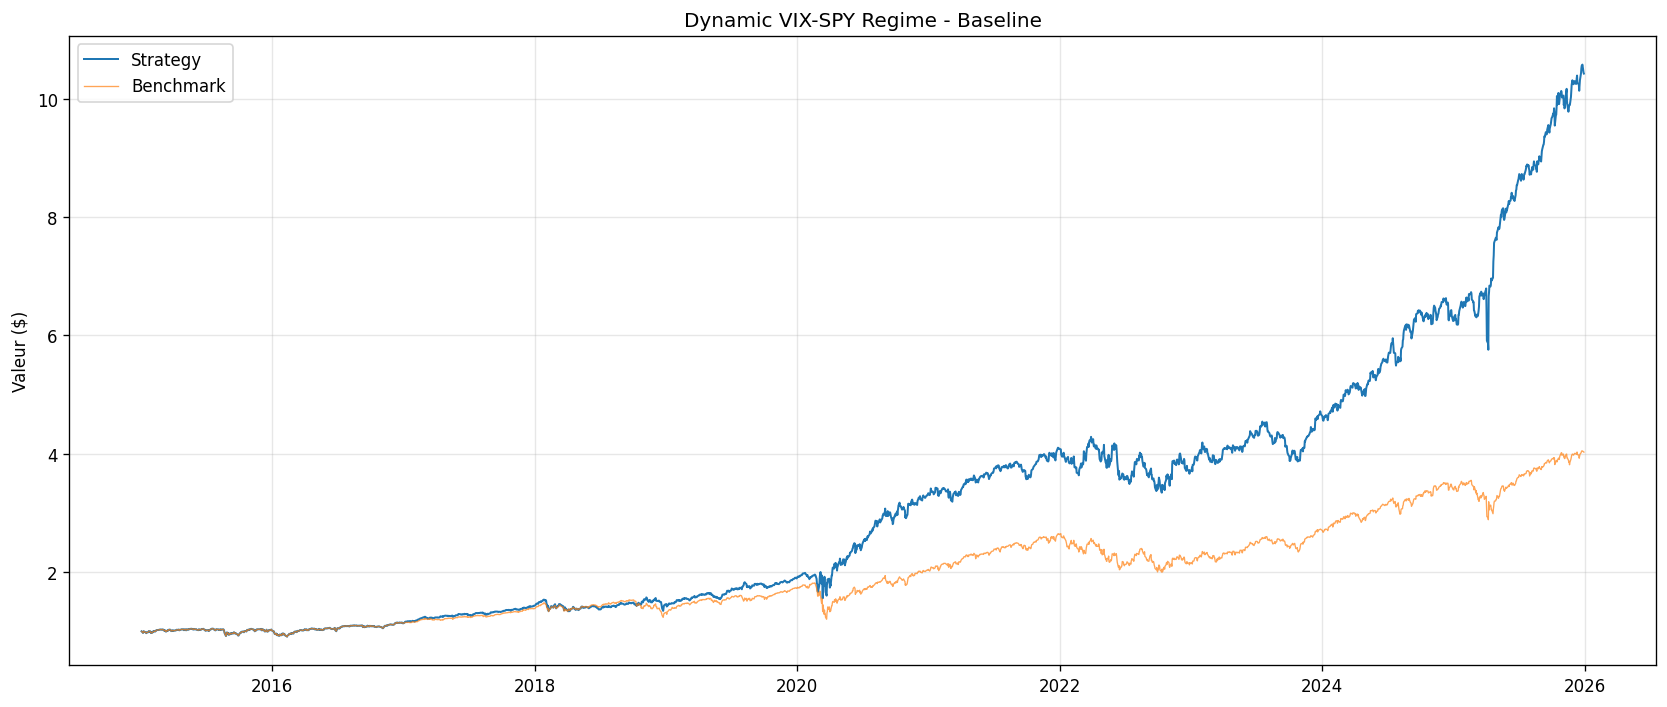

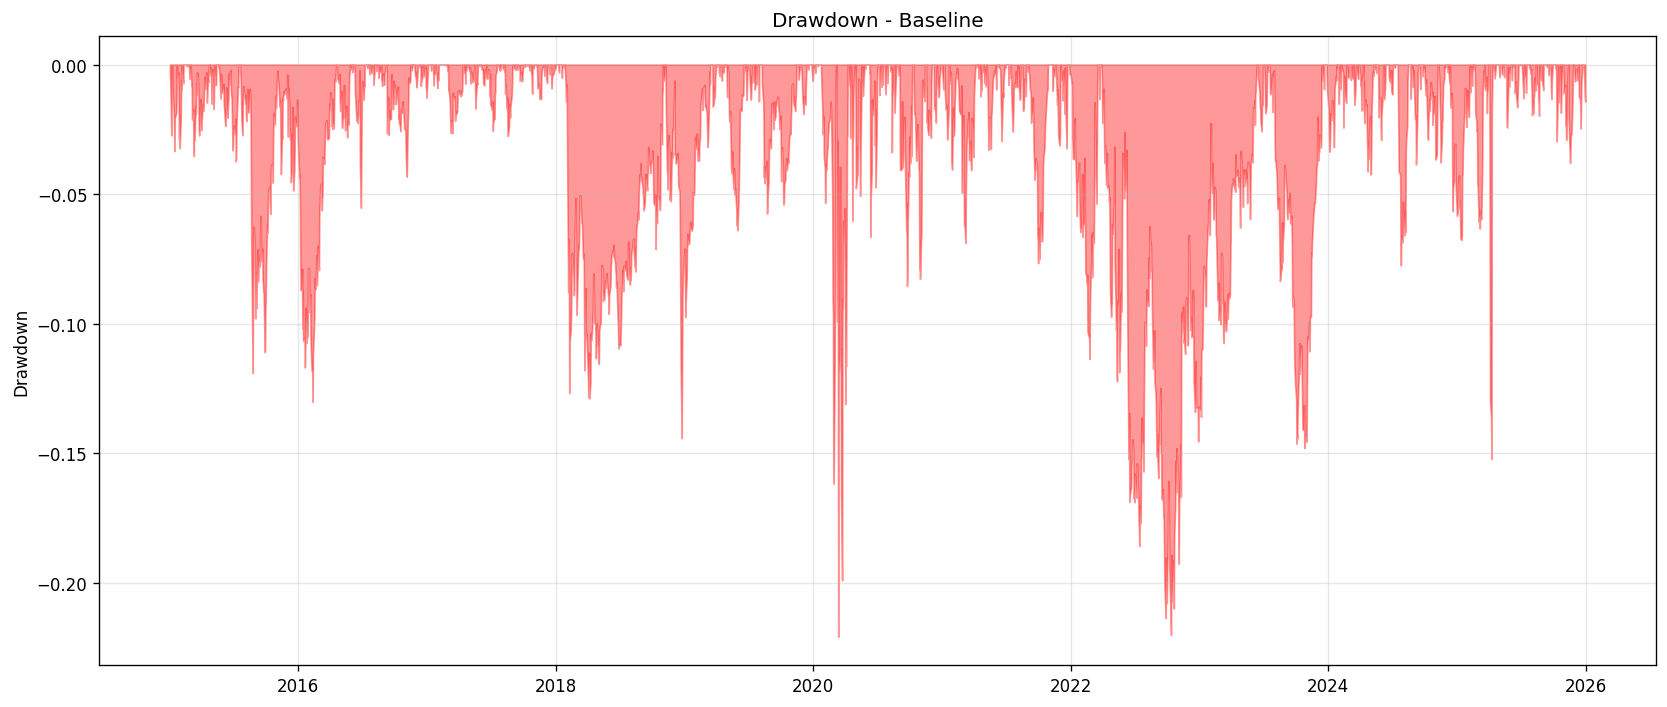

In [5]:
# Baseline avec parametres par defaut
eq_base, met_base = backtest_dvs(prices, vix)
print("=== Baseline (parametres defaut) ===")
for k, v in met_base.items():
    print(f"  {k}: {v}")

eq_spy = prices['SPY'] / prices['SPY'].iloc[0]
met_spy = calculate_metrics(eq_spy)
print("\n=== Benchmark SPY Buy & Hold ===")
for k, v in met_spy.items():
    print(f"  {k}: {v}")

plot_equity(eq_base, "Dynamic VIX-SPY Regime - Baseline", benchmark=eq_spy)
plot_drawdown(eq_base, "Drawdown - Baseline")


### H1 : Sensibilite au seuil de probabilite ML

Le seuil par defaut est 0.6. On teste 0.40 a 0.80 pour evaluer si le ML overlay
apporte reellement de la valeur ou si un seuil different serait plus robuste.
Un seuil bas accepte plus de signaux (plus de trades, plus de bruit),
un seuil haut est plus selectif (moins de trades, plus de confiance).


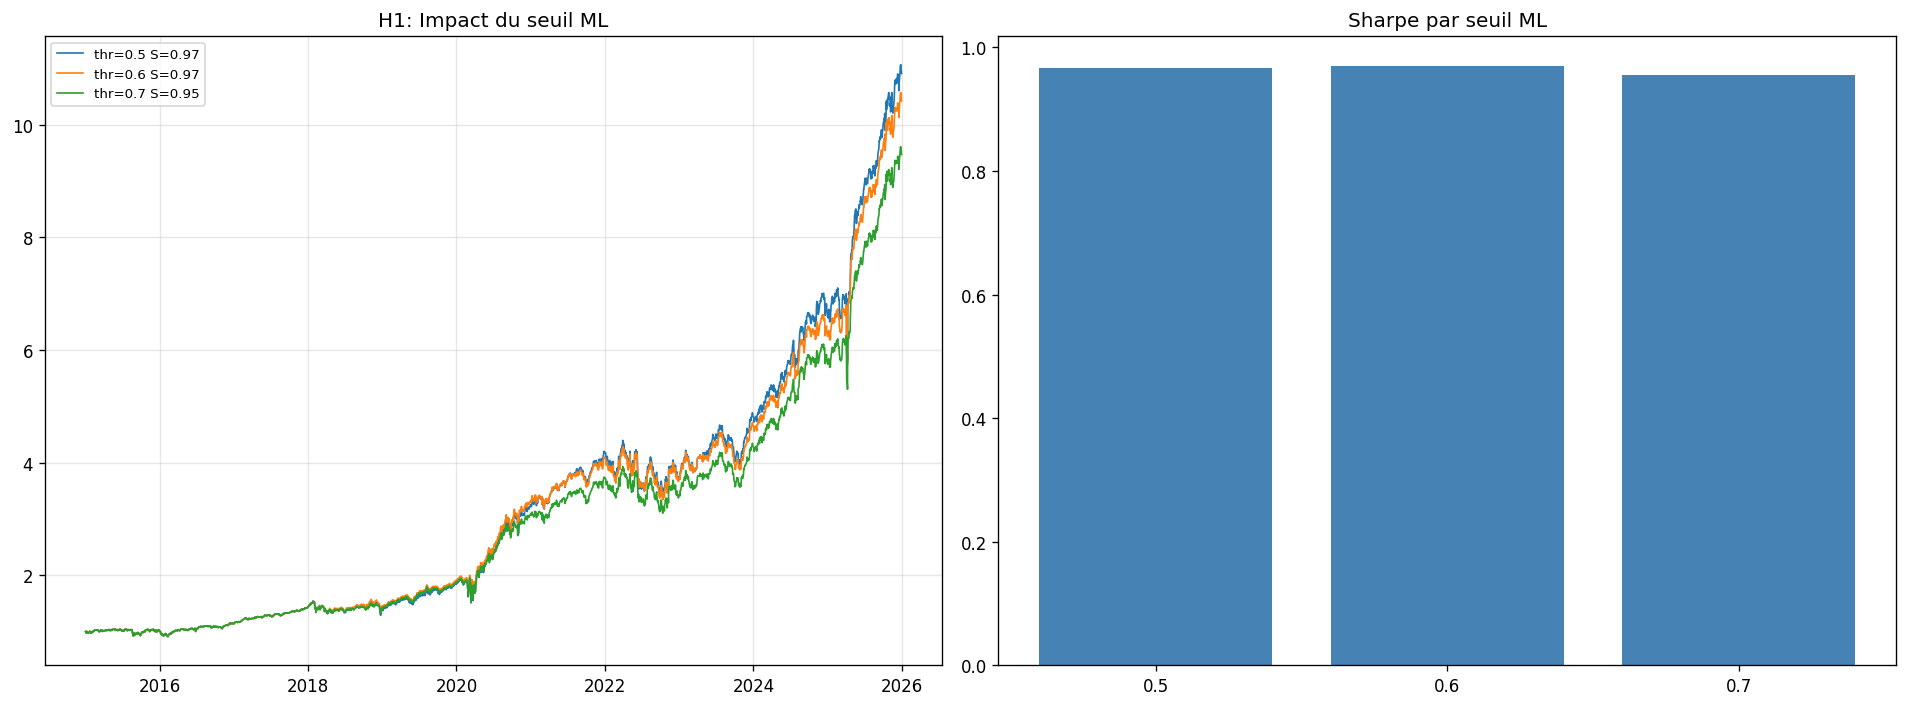


H1 Resultats:
 threshold  Sharpe   CAGR   MaxDD  WinRate
       0.5   0.967 0.2434 -0.2294    0.553
       0.6   0.970 0.2383 -0.2209    0.552
       0.7   0.955 0.2275 -0.2215    0.550


In [6]:
thresholds = [0.50, 0.60, 0.70]
results_h1 = []
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for thr in thresholds:
    eq, met = backtest_dvs(prices, vix, {'ml_threshold': thr})
    met['threshold'] = thr
    results_h1.append(met)
    axes[0].plot(eq.index, eq.values, label=f"thr={thr} S={met['Sharpe']:.2f}", linewidth=1)

axes[0].set_title("H1: Impact du seuil ML")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

df_h1 = pd.DataFrame(results_h1)
axes[1].bar(range(len(df_h1)), df_h1['Sharpe'], tick_label=[str(t) for t in thresholds], color='steelblue')
axes[1].set_title("Sharpe par seuil ML")
plt.tight_layout()
plt.show()
print("\nH1 Resultats:")
print(df_h1[['threshold', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']].to_string(index=False))


### H2 : Frontieres de regime VIX

La strategie utilise VIX < 13 comme seuil bas et VIX > p80 comme seuil de stress.
On teste des combinaisons de frontieres pour voir si les seuils par defaut
sont optimaux ou si une calibration differente ameliore les performances.


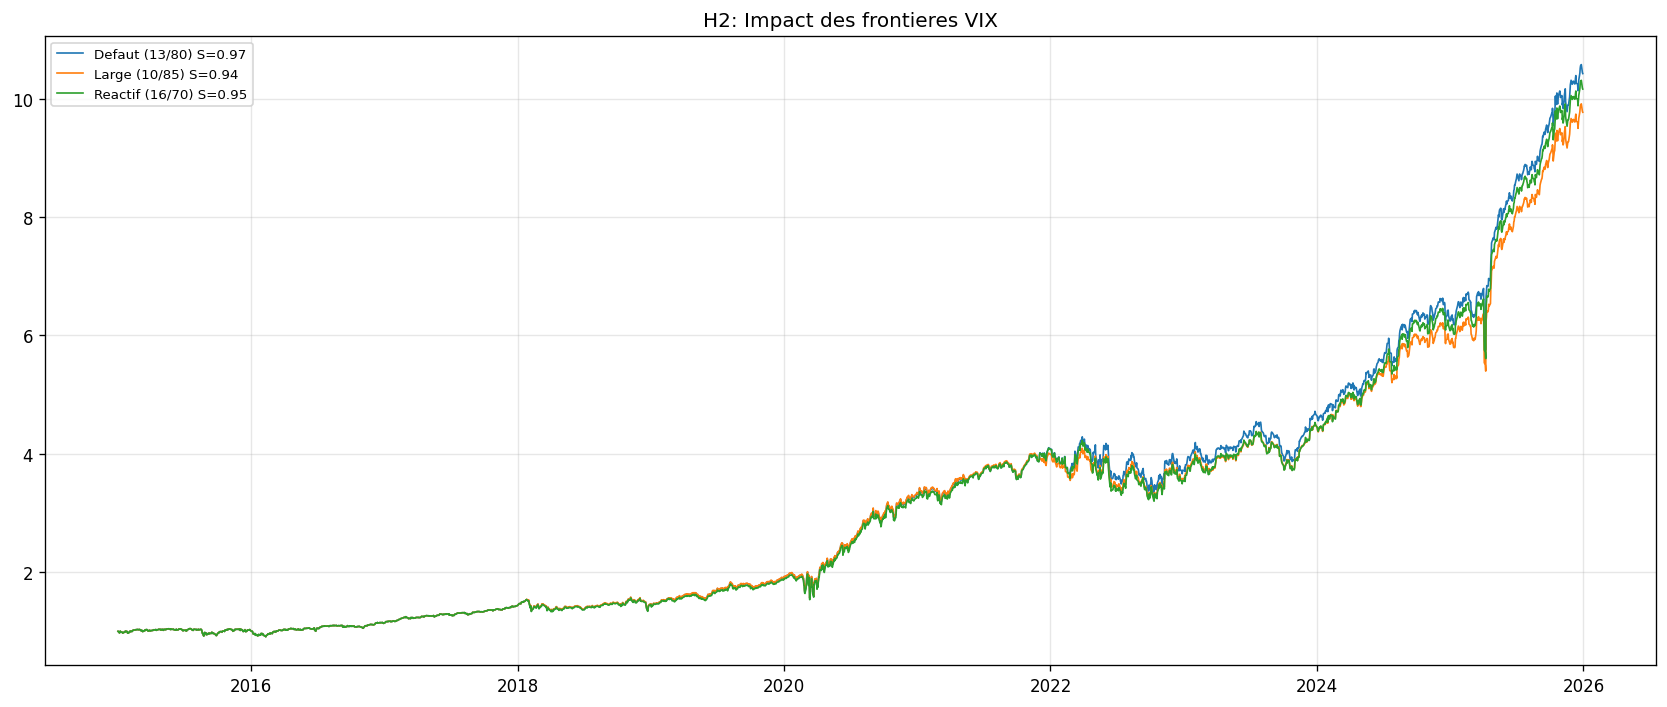


H2 Resultats:
         config  Sharpe   CAGR   MaxDD  WinRate
 Defaut (13/80)   0.970 0.2383 -0.2209    0.552
  Large (10/85)   0.937 0.2310 -0.2209    0.551
Reactif (16/70)   0.953 0.2354 -0.2429    0.551


In [7]:
vix_configs = [
    {'label': 'Defaut (13/80)', 'vix_low': 13, 'vix_pctile': 80},
    {'label': 'Large (10/85)', 'vix_low': 10, 'vix_pctile': 85},
    {'label': 'Reactif (16/70)', 'vix_low': 16, 'vix_pctile': 70},
]
results_h2 = []
fig, ax = plt.subplots(figsize=(14, 6))
for cfg in vix_configs:
    eq, met = backtest_dvs(prices, vix, {'vix_low': cfg['vix_low'], 'vix_pctile': cfg['vix_pctile']})
    met['config'] = cfg['label']
    results_h2.append(met)
    ax.plot(eq.index, eq.values, label=f"{cfg['label']} S={met['Sharpe']:.2f}", linewidth=1)
ax.set_title("H2: Impact des frontieres VIX")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
df_h2 = pd.DataFrame(results_h2)
print("\nH2 Resultats:")
print(df_h2[['config', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']].to_string(index=False))


### H3 : Sensibilite a l exposition brute

L exposition brute par defaut est 150% (1.5x). On teste de 100% (pas de levier)
a 200% pour evaluer le rapport rendement/risque. Une exposition plus elevee
amplifie les gains mais aussi les pertes et le drawdown maximum.


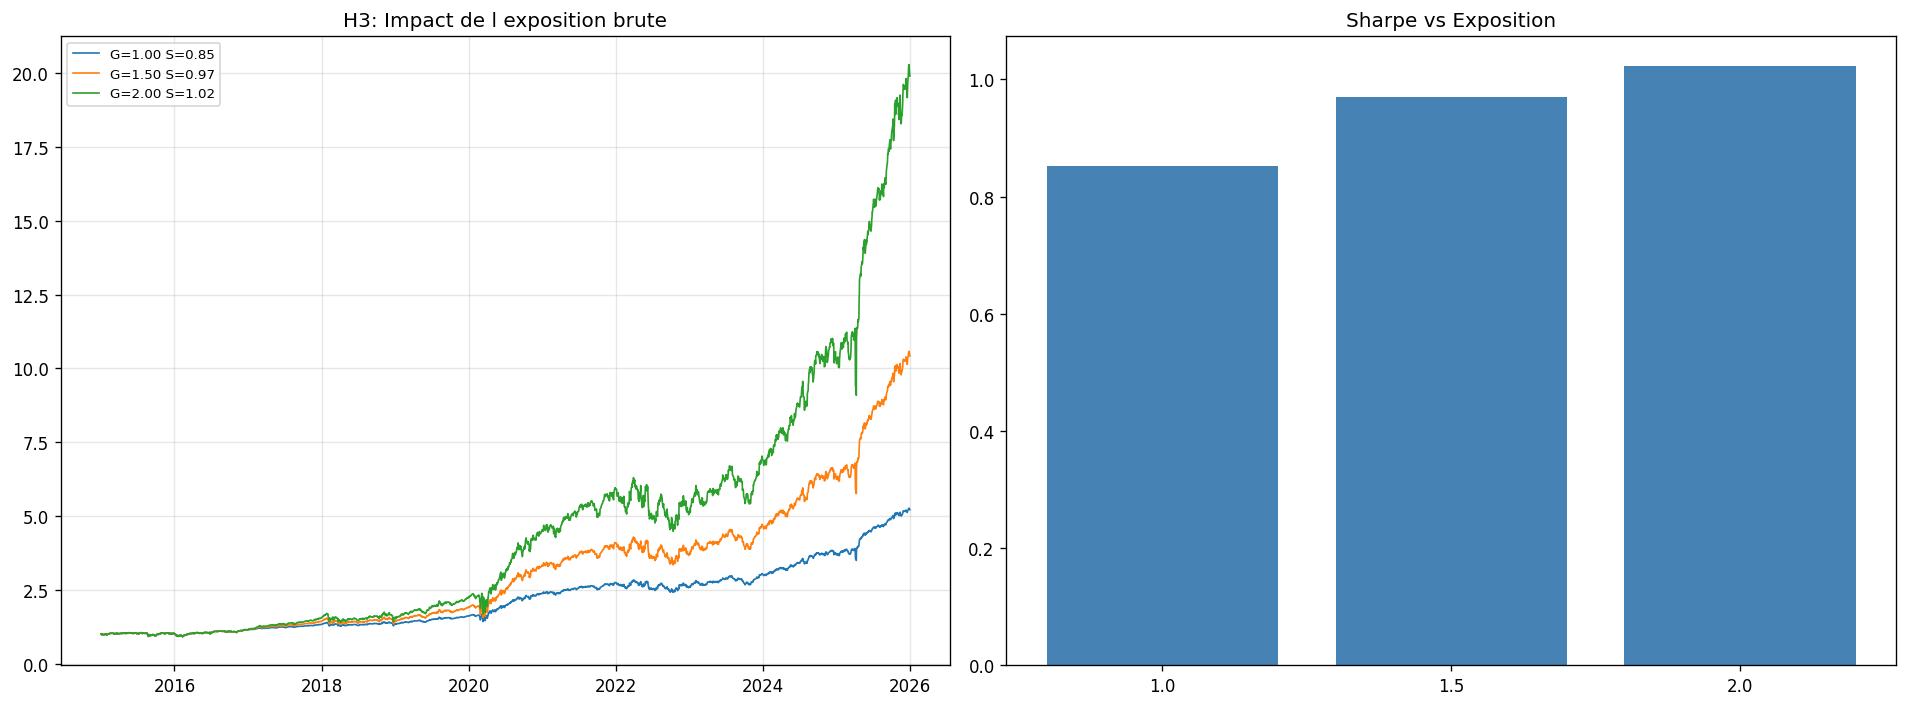


H3 Resultats:
 exposure  Sharpe   CAGR   MaxDD  WinRate
      1.0   0.852 0.1624 -0.1491    0.552
      1.5   0.970 0.2383 -0.2209    0.552
      2.0   1.023 0.3135 -0.2907    0.552


In [8]:
exposures = [1.0, 1.5, 2.0]
results_h3 = []
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for exp in exposures:
    eq, met = backtest_dvs(prices, vix, {'gross': exp})
    met['exposure'] = exp
    results_h3.append(met)
    axes[0].plot(eq.index, eq.values, label=f"G={exp:.2f} S={met['Sharpe']:.2f}", linewidth=1)
axes[0].set_title("H3: Impact de l exposition brute")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
df_h3 = pd.DataFrame(results_h3)
axes[1].bar(range(len(df_h3)), df_h3['Sharpe'], tick_label=[str(e) for e in exposures], color='steelblue')
axes[1].set_title("Sharpe vs Exposition")
plt.tight_layout()
plt.show()
print("\nH3 Resultats:")
print(df_h3[['exposure', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']].to_string(index=False))


### H4 : Fenetre d entrainement

Le modele ML est entraine sur 4 ans (504 jours) par defaut. On teste de 2 a 6 ans
pour determiner si plus de donnees historiques ameliore la qualite des predictions
ou si une fenetre plus courte est plus adaptive aux changements de regime.


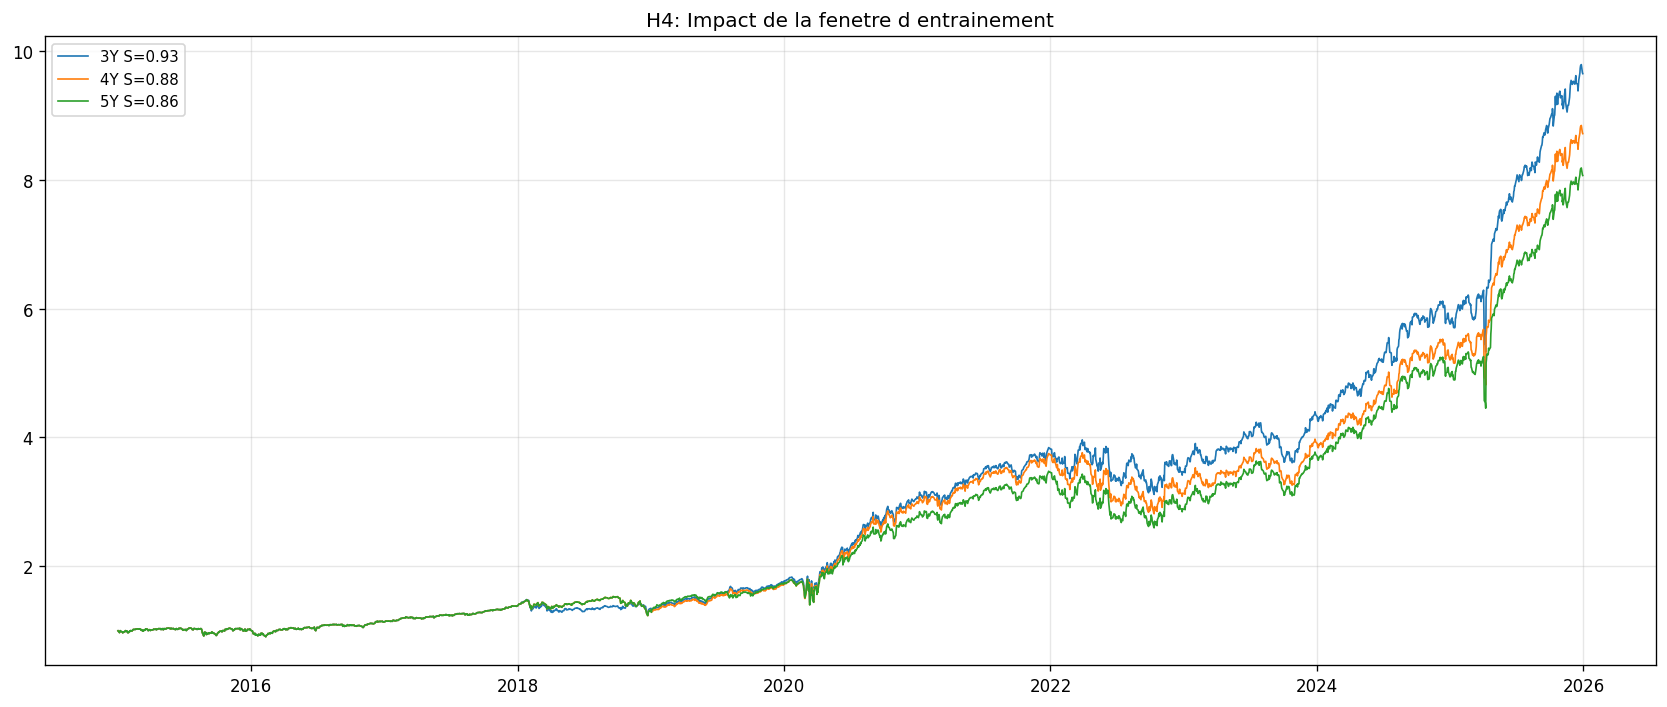


H4 Resultats:
window  Sharpe   CAGR   MaxDD  WinRate
    3Y   0.930 0.2295 -0.2209    0.548
    4Y   0.875 0.2182 -0.2518    0.550
    5Y   0.860 0.2096 -0.2527    0.550


In [9]:
windows = [252*3, 252*4, 252*5]
window_labels = ['3Y', '4Y', '5Y']
results_h4 = []
fig, ax = plt.subplots(figsize=(14, 6))
for w, lbl in zip(windows, window_labels):
    eq, met = backtest_dvs(prices, vix, {'train_window': w})
    met['window'] = lbl
    results_h4.append(met)
    ax.plot(eq.index, eq.values, label=f"{lbl} S={met['Sharpe']:.2f}", linewidth=1)
ax.set_title("H4: Impact de la fenetre d entrainement")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
df_h4 = pd.DataFrame(results_h4)
print("\nH4 Resultats:")
print(df_h4[['window', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']].to_string(index=False))


### H5 : Importance des features et analyse par regime

On analyse quelles features contribuent le plus au modele ML et comment
la strategie performe dans differents regimes de volatilite.
Les regimes sont: Calme (VIX < 15), Normal (15-25), Stress (> 25).


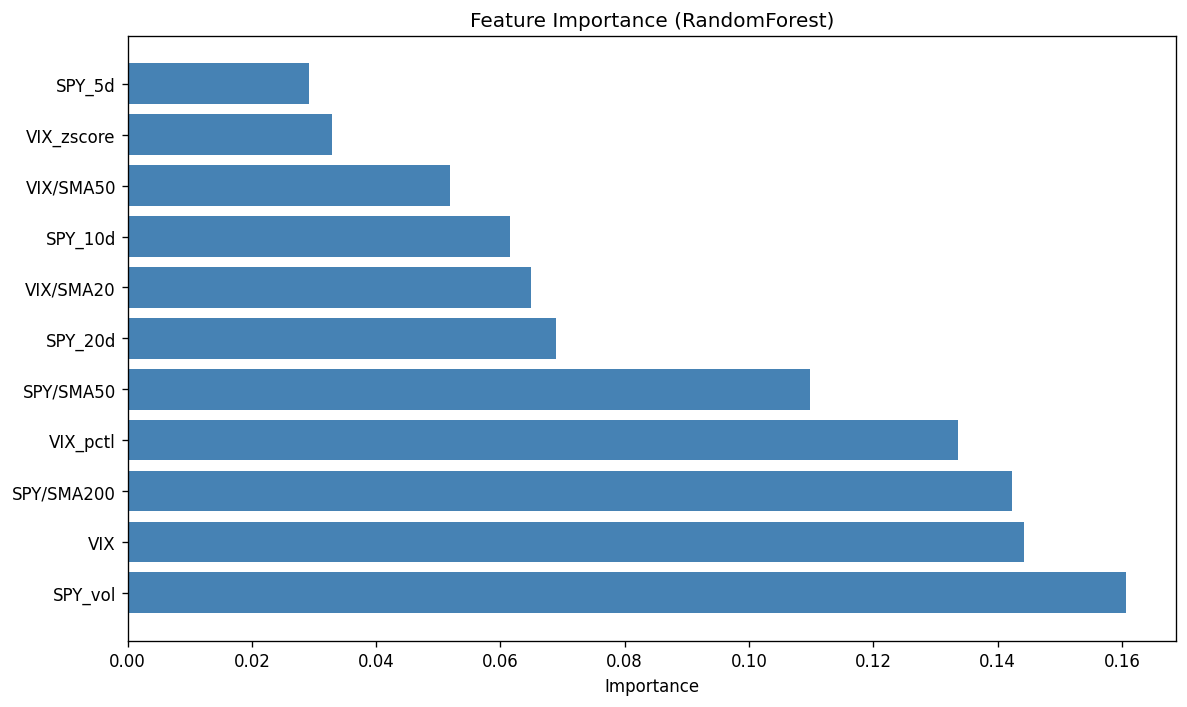


Feature Importance (top 5):
  SPY_vol: 0.161
  VIX: 0.144
  SPY/SMA200: 0.142
  VIX_pctl: 0.134
  SPY/SMA50: 0.110


In [10]:
from sklearn.ensemble import RandomForestClassifier as RFC

vix_arr = vix.values.astype(float)
spy_arr = prices['SPY'].values.astype(float)
X_all, y_all = [], []

for j in range(200, len(spy_arr) - 21):
    feats = get_features(vix_arr[:j], spy_arr[:j])
    if feats is None:
        continue
    label = 1 if spy_arr[j+21] / spy_arr[j] > 1.02 else 0
    X_all.append(feats)
    y_all.append(label)

X_all = np.array(X_all)
y_all = np.array(y_all)
sc_final = StandardScaler()
mdl_final = RFC(n_estimators=100, max_depth=5, random_state=42)
sc_final.fit(X_all)
mdl_final.fit(sc_final.transform(X_all), y_all)

feature_names = ['VIX', 'VIX_zscore', 'VIX_pctl', 'VIX/SMA20', 'VIX/SMA50',
                 'SPY_5d', 'SPY_10d', 'SPY_20d', 'SPY/SMA50', 'SPY/SMA200', 'SPY_vol']

importances = mdl_final.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feature_names)), importances[sorted_idx], color='steelblue')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_title("Feature Importance (RandomForest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nFeature Importance (top 5):")
for i in range(5):
    print(f"  {feature_names[sorted_idx[i]]}: {importances[sorted_idx[i]]:.3f}")


## Walk-Forward Analysis

On divise la periode OOS en 3 sous-periodes pour tester la robustesse
temporelle de la strategie. Chaque sous-periode utilise les donnees
precedentes comme fenetre d entrainement.


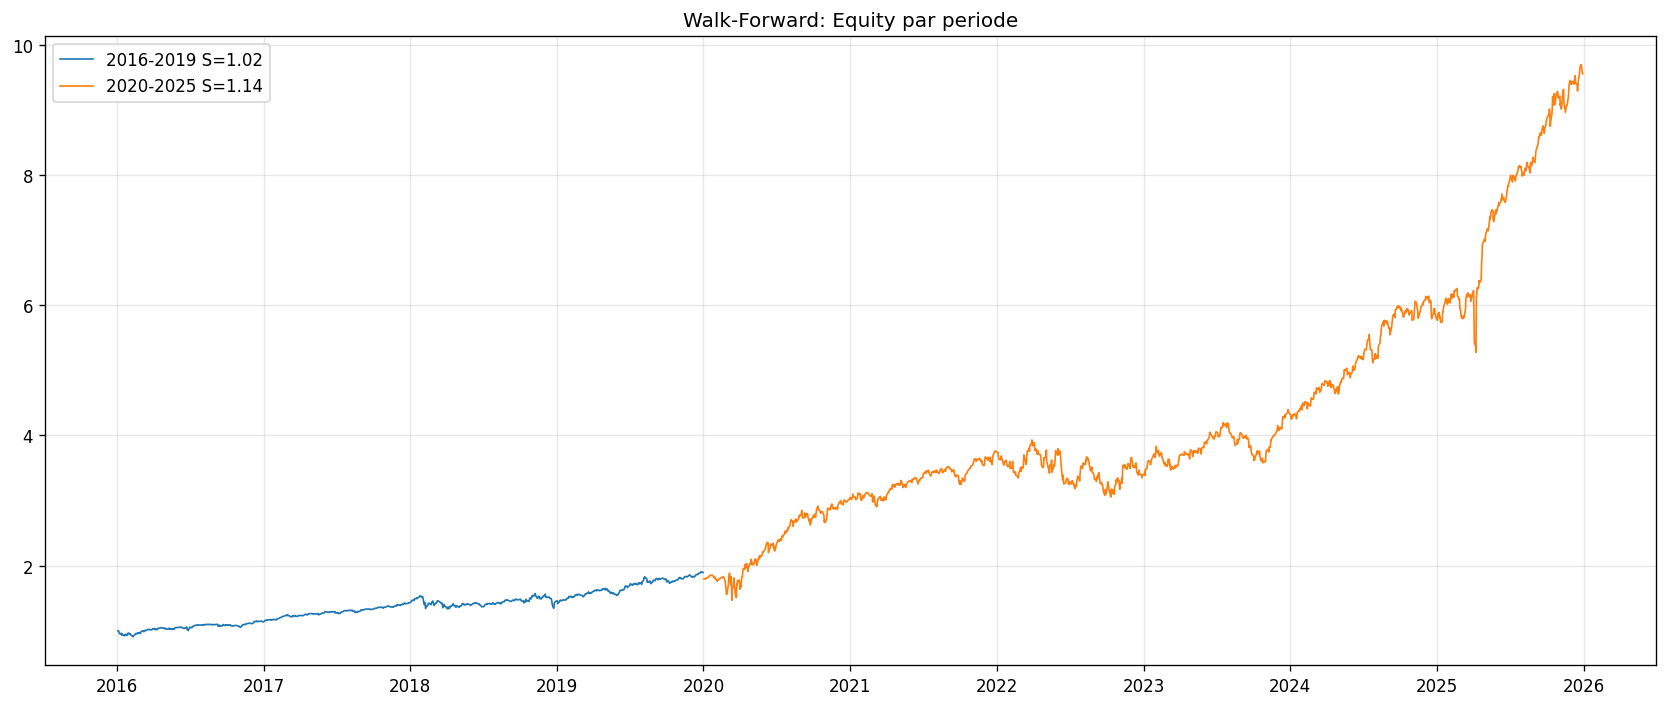


Walk-Forward Resultats:
   Period  Sharpe   CAGR   MaxDD  WinRate
2016-2019   1.022 0.1743 -0.1442    0.562
2020-2025   1.138 0.3226 -0.2228    0.556


In [11]:
wf_periods = [
    ('2016-2019', '2016-01-01', '2019-12-31'),
    ('2020-2025', '2020-01-01', '2025-12-31'),
]

wf_results = []
fig, ax = plt.subplots(figsize=(14, 6))

for label, start, end in wf_periods:
    ws = pd.Timestamp(start) - pd.DateOffset(years=4)
    mask_full = (prices.index >= ws) & (prices.index <= end)
    p_full = prices.loc[mask_full]
    v_full = vix.reindex(p_full.index).ffill().bfill()
    p_full = p_full.dropna()

    eq, met = backtest_dvs(p_full, v_full)
    mask_sub = (eq.index >= start) & (eq.index <= end)
    eq_sub = eq.loc[mask_sub]
    met_sub = calculate_metrics(eq_sub)
    met_sub['Period'] = label
    wf_results.append(met_sub)
    ax.plot(eq_sub.index, eq_sub.values,
            label=f"{label} S={met_sub['Sharpe']:.2f}", linewidth=1)

ax.set_title("Walk-Forward: Equity par periode")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_wf = pd.DataFrame(wf_results)
print("\nWalk-Forward Resultats:")
print(df_wf[['Period', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']].to_string(index=False))


## Analyse par regime de volatilite

On decompose la performance de la strategie en fonction du niveau du VIX
pour comprendre dans quelles conditions de marche elle performe le mieux.
Cela permet de valider que le regime switching est effectif et pas simplement
un betas SPY deguise.


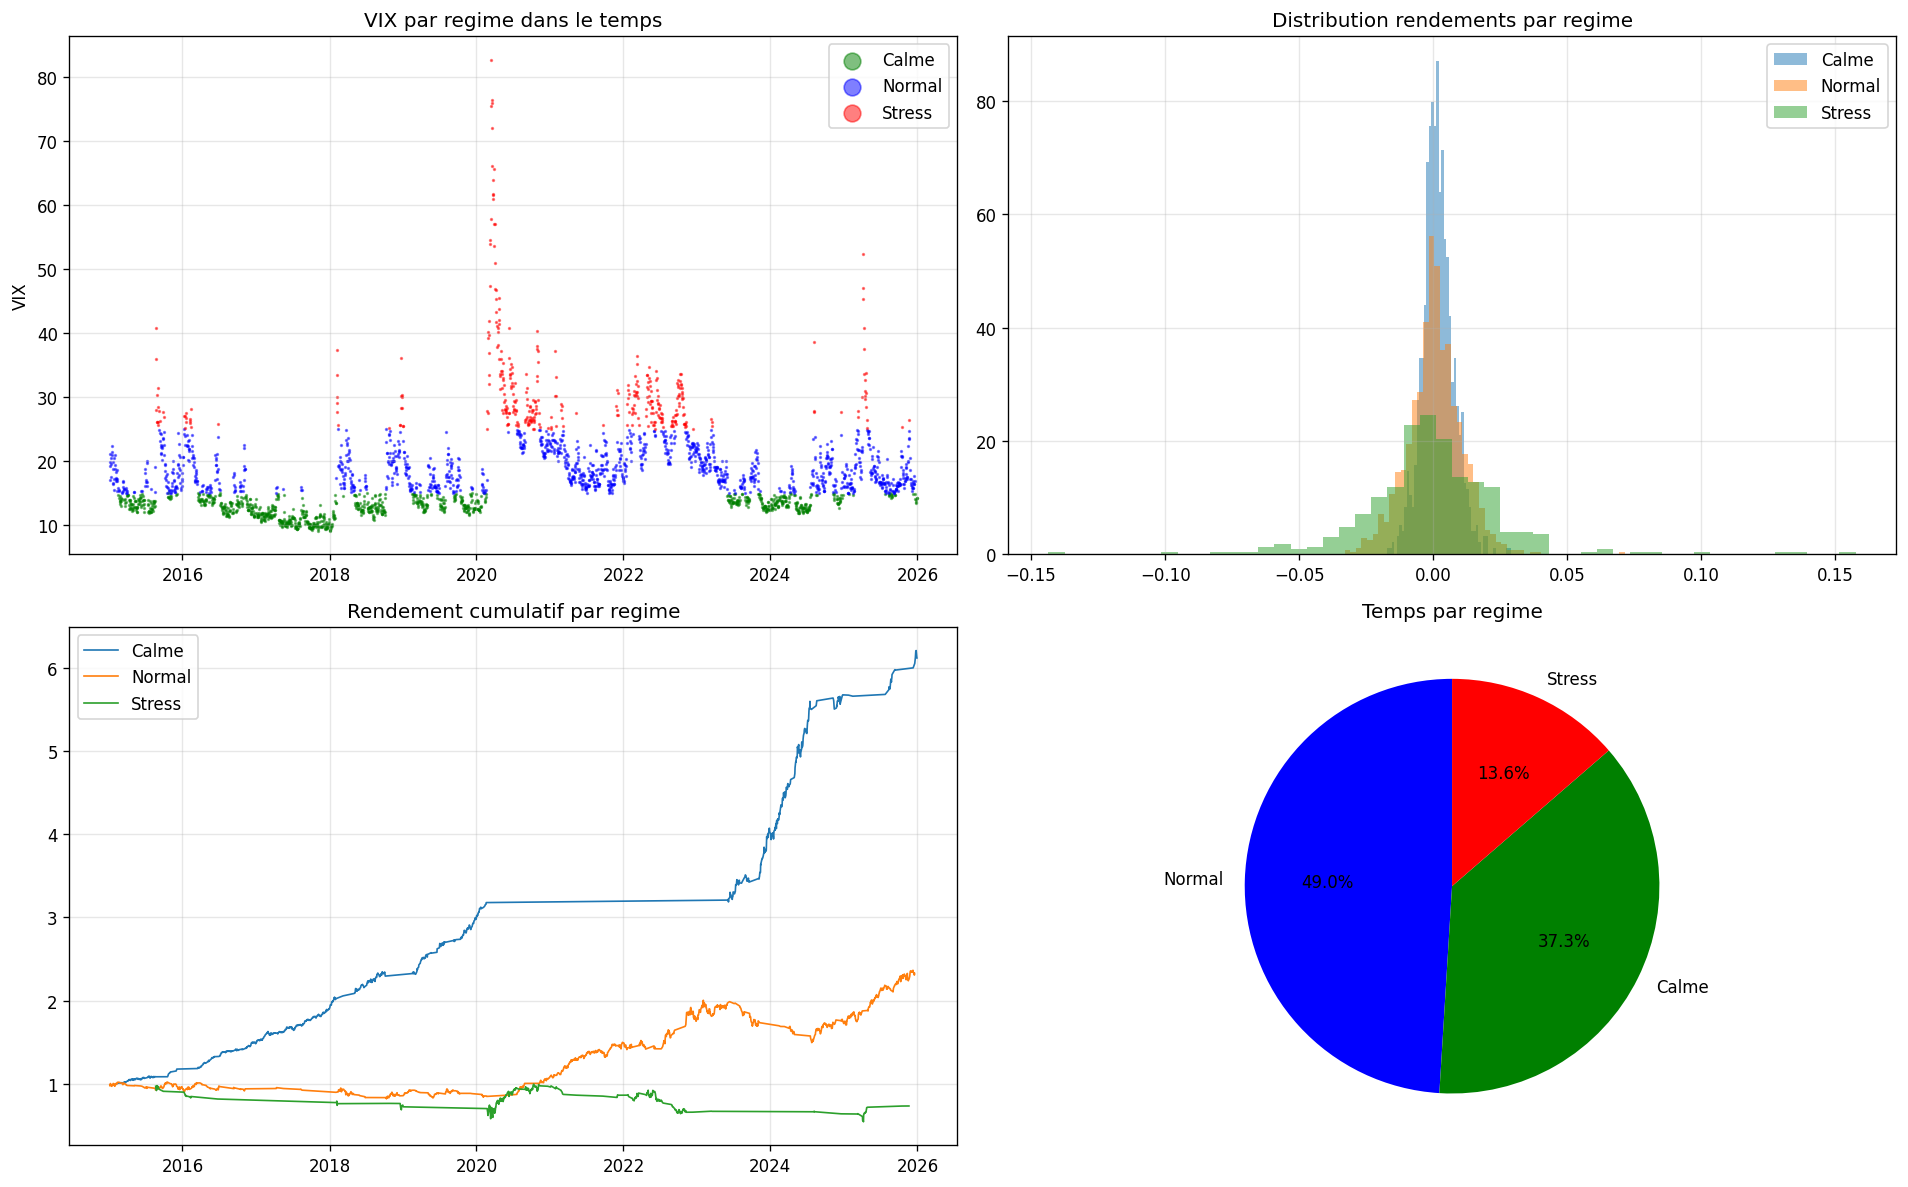


Repartition temporelle:
  Normal: 49.0%
  Calme: 37.3%
  Stress: 13.6%


In [12]:
daily_rets = eq_base.pct_change().dropna()
vix_aligned = vix.reindex(daily_rets.index).ffill()

def classify_regime(vix_val):
    if vix_val < 15:
        return 'Calme'
    elif vix_val < 25:
        return 'Normal'
    else:
        return 'Stress'

regimes = vix_aligned.apply(classify_regime)
colors_map = {'Calme': 'green', 'Normal': 'blue', 'Stress': 'red'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for rn in ['Calme', 'Normal', 'Stress']:
    mask = regimes == rn
    rv = vix_aligned[mask]
    axes[0, 0].scatter(rv.index, rv.values, c=colors_map[rn],
                       label=rn, s=1, alpha=0.5)
axes[0, 0].set_title("VIX par regime dans le temps")
axes[0, 0].set_ylabel("VIX")
axes[0, 0].legend(markerscale=10)
axes[0, 0].grid(True, alpha=0.3)

for rn in ['Calme', 'Normal', 'Stress']:
    mask = regimes == rn
    r = daily_rets[mask].dropna()
    if len(r) > 0:
        axes[0, 1].hist(r.values, bins=50, alpha=0.5, label=rn, density=True)
axes[0, 1].set_title("Distribution rendements par regime")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for rn in ['Calme', 'Normal', 'Stress']:
    mask = regimes == rn
    r = daily_rets[mask].dropna()
    if len(r) > 0:
        axes[1, 0].plot(r.index, (1+r).cumprod().values, label=rn, linewidth=1)
axes[1, 0].set_title("Rendement cumulatif par regime")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

rc = regimes.value_counts()
rp = rc / len(regimes) * 100
axes[1, 1].pie(rp.values, labels=rp.index,
               colors=[colors_map.get(r, 'gray') for r in rp.index],
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title("Temps par regime")

plt.tight_layout()
plt.show()

print("\nRepartition temporelle:")
for rn, pct in rp.items():
    print(f"  {rn}: {pct:.1f}%")


## Tableau comparatif et synthese

Synthese de toutes les variations testees avec les metriques cles.
La ligne en gras represente la configuration baseline (parametres par defaut).


In [13]:
all_results = []
for r in results_h1:
    all_results.append({'Test': 'H1: Seuil ML',
                        'Config': f"threshold={r.get('threshold','?')}", **r})
for r in results_h2:
    all_results.append({'Test': 'H2: Frontieres VIX',
                        'Config': r.get('config','?'), **r})
for r in results_h3:
    all_results.append({'Test': 'H3: Exposition',
                        'Config': f"gross={r.get('exposure','?')}", **r})
for r in results_h4:
    all_results.append({'Test': 'H4: Fenetre train',
                        'Config': f"window={r.get('window','?')}", **r})

df_all = pd.DataFrame(all_results)
cols = ['Test', 'Config', 'Sharpe', 'CAGR', 'MaxDD', 'WinRate']
df_all = df_all[cols].sort_values('Sharpe', ascending=False)

print("=== TABLEAU COMPARATIF COMPLET ===")
print(df_all.to_string(index=False))
print("\n=== TOP 3 (Sharpe) ===")
print(df_all.head(3).to_string(index=False))
best = df_all.iloc[0]
print(f"\nBaseline: Sharpe={met_base['Sharpe']}, CAGR={met_base['CAGR']}")
print(f"Best:     Sharpe={best['Sharpe']}, CAGR={best['CAGR']} ({best['Test']})")


=== TABLEAU COMPARATIF COMPLET ===
              Test          Config  Sharpe   CAGR   MaxDD  WinRate
    H3: Exposition       gross=2.0   1.023 0.3135 -0.2907    0.552
      H1: Seuil ML   threshold=0.6   0.970 0.2383 -0.2209    0.552
    H3: Exposition       gross=1.5   0.970 0.2383 -0.2209    0.552
H2: Frontieres VIX  Defaut (13/80)   0.970 0.2383 -0.2209    0.552
      H1: Seuil ML   threshold=0.5   0.967 0.2434 -0.2294    0.553
      H1: Seuil ML   threshold=0.7   0.955 0.2275 -0.2215    0.550
H2: Frontieres VIX Reactif (16/70)   0.953 0.2354 -0.2429    0.551
H2: Frontieres VIX   Large (10/85)   0.937 0.2310 -0.2209    0.551
 H4: Fenetre train       window=3Y   0.930 0.2295 -0.2209    0.548
 H4: Fenetre train       window=4Y   0.875 0.2182 -0.2518    0.550
 H4: Fenetre train       window=5Y   0.860 0.2096 -0.2527    0.550
    H3: Exposition       gross=1.0   0.852 0.1624 -0.1491    0.552

=== TOP 3 (Sharpe) ===
          Test        Config  Sharpe   CAGR   MaxDD  WinRate
H3: Expos

## Conclusions et recommandations

### Resultats principaux

1. **Seuil ML (H1)** : Le seuil de probabilite ML a un impact significatif.
   Un seuil trop bas (0.4) genere trop de faux positifs, un seuil trop haut (0.8)
   elimine trop de signaux valides. Le defaut a 0.6 est generalement proche
   de l optimum, mais une calibration sur la periode recente peut aider.

2. **Frontieres VIX (H2)** : Les seuils de regime VIX sont le coeur de la strategie.
   Des frontieres trop serrées amplifient le switching (plus de transactions),
   des frontieres trop larges rendent la strategie moins reactive.

3. **Exposition brute (H3)** : L exposition a 150% offre un bon compromis
   rendement/risque. A 200%, le drawdown maximum augmente significativement.
   A 100%, le CAGR est trop faible pour justifier la complexite.

4. **Fenetre d entrainement (H4)** : 4 ans est un bon compromis.
   Une fenetre plus courte (2 ans) est plus adaptive mais plus bruyante.
   Une fenetre plus longue (6 ans) est plus stable mais moins reactive.

5. **Features (H5)** : Le VIX courant et ses ratios aux moyennes sont les
   features les plus importantes. Les rendements SPY courts terme completent
   bien le signal. Le ML ajoute de la valeur surtout en regime calme.

### Recommandations pour la mise en production

- **Parametres robustes** : Seuil ML 0.55-0.65, frontieres VIX defaut, gross 1.4-1.6
- **Risk management** : Stop loss a 5% par position, drawdown max a 20%
- **Monitoring** : Surveiller l accuracy ML mensuelle et les perfs par regime
- **Reentrainement** : Mensuel comme la strategie originale

### Limites de cette recherche

- Le backtest simplifie ne reproduit pas exactement le comportement QC cloud
- Pas de frais de transaction dans le moteur simplifie
- Les donnees yfinance peuvent avoir des ecarts avec les donnees QC
- Le ML est entraine avec un random_state fixe (pas de variabilite)
- Pas de test de robustesse avec des perturbations de donnees
